In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [ ]:
x,y = make_blobs(n_samples=115,centers=2,n_features=2,cluster_std=0.8)

In [ ]:
y = y.reshape(-1,1)

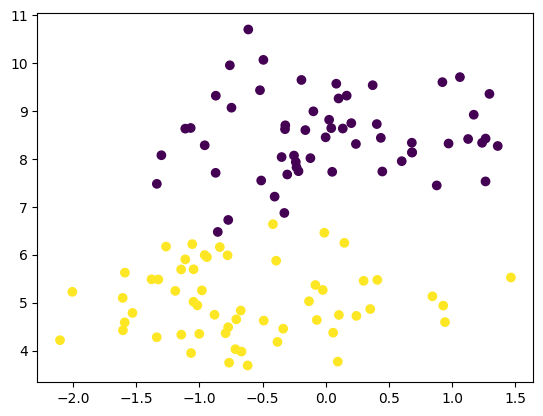

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)

plt.show()

In [ ]:
x = torch.tensor(x,dtype=torch.float32)
y = torch.tensor(y,dtype=torch.float32)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=43)

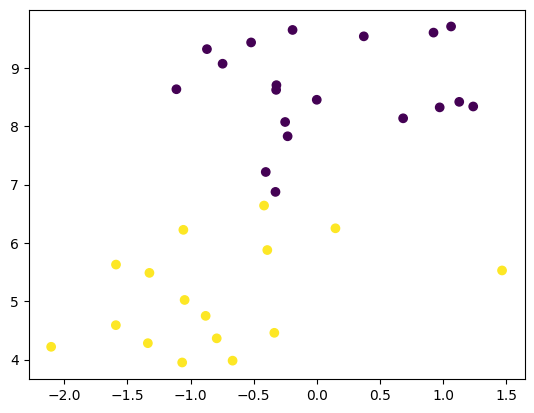

In [ ]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test)
plt.show()

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.fc1 = torch.nn.Linear(in_features=input, out_features=8)
        self.fc2 = torch.nn.Linear(in_features=8, out_features=output)
        self.act =torch.nn.Sigmoid()
        # Activation function


    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)

        # out = torch.sigmoid(x)
        out = self.act(x)
        return out

In [ ]:
model = Net(2,1)

In [ ]:
criterion = torch.nn.BCELoss()
lr = 0.01
optimizer = torch.optim.Adam(model.parameters(),lr=lr)

In [ ]:
def train(model, optimizer, criterion,  x_train, y_train, epochs=50, print_every=5):


  history_loss = []
  history_accuracy = []
  n = len(y_test)

  for epoch in range(epochs):

    # Clear the previous gradients to avoid accumulation.
    optimizer.zero_grad()

    # Calculate predicted values.
    y_hat = model(x_train)

    # Compute the loss between predicted values and actual targets.
    loss = criterion(y_hat, y_train)

    # Update the total loss.
    history_loss.append(loss.item())

    # Evaluate the model on the test dataset.
    pred = model(x_test)
    acc = (sum((pred>.5)==y_test)/n)*100

    # Update the total accuracy.
    history_accuracy.append(acc.item())



    # Compute gradients of the loss with respect to model parameters.
    loss.backward()

    # Update the model parameters using the computed gradients.
    optimizer.step()

    # Print the loss and accuracy every epoch.
    if epoch%print_every==0:
      print(f'epoch {epoch}, \t loss {loss.item():0.2f} \t acc: {acc.item()}')

  return history_loss, history_accuracy

In [ ]:
history_loss, history_accuracy=train(model,optimizer, criterion,  x_train, y_train)

epoch 0, 	 loss 0.81 	 acc: 54.28571701049805
epoch 5, 	 loss 0.64 	 acc: 85.71428680419922
epoch 10, 	 loss 0.63 	 acc: 77.14286041259766
epoch 15, 	 loss 0.60 	 acc: 74.28571319580078
epoch 20, 	 loss 0.58 	 acc: 74.28571319580078
epoch 25, 	 loss 0.56 	 acc: 85.71428680419922
epoch 30, 	 loss 0.54 	 acc: 85.71428680419922
epoch 35, 	 loss 0.53 	 acc: 85.71428680419922
epoch 40, 	 loss 0.51 	 acc: 88.57142639160156
epoch 45, 	 loss 0.50 	 acc: 85.71428680419922


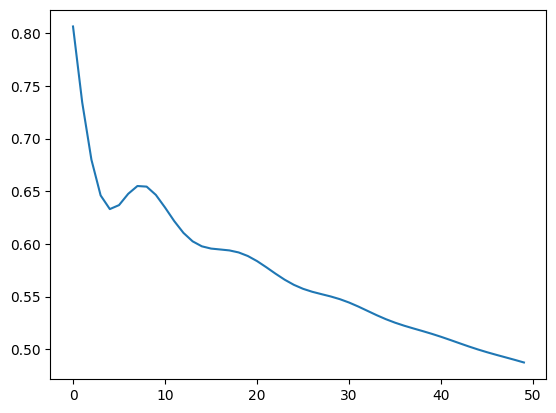

In [ ]:
plt.plot(history_loss)
plt.show()